# Earnings Return Prediction Challenge - Starter Template (v7 20240419)

In this project we will train a model to predict the stock return on the day of earnings for US companies. This template contains code to get you started with the project.

## Standard imports

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

import warnings
warnings.filterwarnings("ignore")

## Notebook configuration
- Please set the **<span style="color:red">config['enddate']</span>** to the most recent Friday. Do not change any other config parameters. 

- The environment might take around one minute to load
- The  **Operators** are functions that can be used to apply a series of transformations to a data variable or alpha.
> [Introduction to Operators](https://trexsim.com/trexsim/pysim/tutorial2022/operators.html)
> 
> Find all available  operators in the [operators list](https://www.trexsim.com/trexsim/pysim/comptutorial/operators.html)

In [2]:
import operators as op              # find all available operators, https://www.trexsim.com/trexsim/pysim/comptutorial/operators.html
import utilities as utils
import strategy_utilities as sutil
from strategy_research import load_env

config = {
    'enddate': 20240920,            # Please setting the config['enddate'] to the most recent Friday.
    'region': 'USA',
    'universe': 'top3000',
    'delay': 0,
    'booksize':1e6,
    'refit_interval': 'OneQuarter',
    'filter_function_uuid': 'none',
    'fit_function_uuid': 'none',
    'pp_function_uuid': 'none',
    'tf_function_uuid': 'none',
    'postalpha': False,
    'compress': False,    
    'load_cache': False,
    'save_cache': False,
    'skip_post_strategy': True,
    'skip_test_cases': True,
    'strat_dir': './'
}

def tf_function(preA, data): return preA
function_dict = {'tf_function': tf_function}

env = load_env('USA')
data = sutil.create_strategy_data(function_dict, config, 'full', env, use_pre_compressed=True)
data = sutil.add_builtin_functions(data, function_dict, config, env)

is container True
Variable numdates is loaded from /home/newprod/production/data/USA/simvars/numdates/numdates.20240920.raw.mat
Variable numstocks is loaded from /home/newprod/production/data/USA/simvars/numstocks/numstocks.20240920.raw.mat
Variable dates is loaded from /home/newprod/production/data/USA/simvars/dates/dates.20240920.raw.mat
Variable dates is loaded from /home/newprod/production/data/USA/simvars/dates/dates.20240920.adj_amend.mat 4711
Variable numdates is loaded from /home/newprod/production/data/USA/simvars/numdates/numdates.20240920.adj_amend.mat 4711
Variable startdate is loaded from /home/newprod/production/data/USA/simvars/startdate/startdate.20240920.adj_amend.mat 4711
Variable enddate is loaded from /home/newprod/production/data/USA/simvars/enddate/enddate.20240920.adj_amend.mat 4711
Variable spread_timeweighted_allday is loaded from /home/newprod/production/data/USA/simvars/spread_timeweighted_allday/spread_timeweighted_allday.20240920.adj_amend.ci 4711
Variable 

## **Mask**

Most data variables at Trexquant are 2D matrices with dimensions _num\_stocks_ x _num\_dates_. We want to filter on the dates when earnings were announced and convert the 2D matrix to a vector so that it can be used in an ML model.

To find the earnings date we use the data variable [trading_days_til_next_ann](https://www.trexsim.com/trexsim/pysim/data_description/variable/USA/trading_days_til_next_ann/). We also require the time of announcement which we get from the data variable [fs_next_ann_time](https://www.trexsim.com/trexsim/pysim/data_description/variable/USA/fs_next_ann_time/). We use the following logic to construct the mask:
1. If the annoucement time is before the trading time (1500), set the earnings return day as today.
2. If the annoucement time is after the trading time (1500), set the earnings return day as the next day.

The code in the cell below constructs the mask

In [3]:
### ---- ---- ---- ---- No need to modify the code below ---- ---- ---- ---- ###

# contruct earning mask based on trading_days_til_next_ann
valid_mask = (data['load_simvar_hhmm']('trading_days_til_next_ann') == 1)
fs_next_ann_time = data['load_simvar_hhmm']('fs_next_ann_time')

# based on trading_days_til_next_ann and fs_next_ann_time
# delay one day if earnings is announced after we trade
valid_effect_mask = np.zeros_like(valid_mask, dtype=np.float32)
for si, di in zip(*np.where((valid_mask == 1) & (data['valids']))):

    # skip if we are unable to get the target
    if di + data['delay'] >= data['numdates']:
        continue

    time = fs_next_ann_time[si, di]

    if time <= 1500:
        target_di = di
    elif time > 1500 and di + 1 < data['numdates']:
        target_di = di+1
    if valid_effect_mask[si, target_di] != 1:
        valid_effect_mask[si, target_di] = 1
        
bet_days_mask = valid_effect_mask==1
bet_days_mask = op.at_nan2zero(bet_days_mask*1.0)
flatten_mask = (bet_days_mask==1.0)

## **Target**

For this challenge we will use one-day forward ret1_excess as the target
- target columns: `target`, which is the forward [ret1_excess](https://www.trexsim.com/trexsim/pysim/data_description/variable/USA/ret1_excess/)
- dates: `dates` column is the masked dates, which is the day we want to enter our position before the earning announcement.
- stock index: `si`
- date index: `di`
- `[si,di]` data point indicates that we want to enter into the position for the stock at si th index and di th date just before the company announces its results

In [4]:
### ---- ---- ---- ---- No need to modify the code below ---- ---- ---- ---- ###

ret1_excess = data['load_simvar_hhmm']('ret1_excess')
fwd_ret = op.ts_delay((ret1_excess),-1) # one day forward ret1_excess

# modify mask to remove points where target is invalid
flatten_mask[np.isnan(fwd_ret)] = False  
target = fwd_ret[flatten_mask]

# put target into the dataframe
df = pd.DataFrame()
df['target'] = target

num_of_stocks, num_of_dates = ret1_excess.shape
si_list = np.array([list(np.arange(num_of_stocks))]*num_of_dates).transpose()
di_list = np.array([list(np.arange(num_of_dates))]*num_of_stocks)

df['si'] = si_list[flatten_mask]
df['di'] = di_list[flatten_mask]
dates_mat = np.tile(data['dates'], (num_of_stocks,1))
df['dates'] = dates_mat[flatten_mask]

## **Features**

For this challenge you can use any of the data variables available in the [data description](https://trexsim.com/trexsim/pysim/data_description/USA/).
You may further apply any transformations to the data variables that you deem appropriate.

Please keep in mind that **all features used must be dimensionless**. Features that have dimensions of price of number of shares are subject to adjustment which introduces a forward bias. An easy way to check if a data variable is subject to adjustment is to check if there is anything in the `adjfactor_type` column in the data description.
Features which are subject to adjustment can be normalized using operators like `ts_zscore`, `ts_norm` and `ts_std_normalized`. Find all available operators in [operators list](https://www.trexsim.com/trexsim/pysim/comptutorial/operators.html).

You can combine existing features and apply operators to make new features as long as the transformations are reasonable.

In the followint cell, you will see 3 feature used in the benchmark model.
- [ret1](https://www.trexsim.com/trexsim/pysim/data_description/variable/USA/ret1/): On day return.
- [linkup_job_active_count](https://www.trexsim.com/trexsim/pysim/data_description/variable/USA/linkup_job_active_count/): number of active jobs.

In [71]:

import numpy as np
from sklearn.preprocessing import MinMaxScaler
def cs_MinMaxScaler(alpha_matrix, min=-5.0, max=5.0):
    numstocks, numdates = alpha_matrix.shape
    scaler = MinMaxScaler(feature_range=(min, max))
    scaled_matrix = np.zeros_like(alpha_matrix)
    for i in range(numdates):
        column = alpha_matrix[:, i].reshape(-1, 1)
        scaled_matrix[:, i] = scaler.fit_transform(column).flatten()
    return scaled_matrix

def normalize_features(alpha):
    MIN,MAX = -4.0, 4.0
    alpha = op.cs_winsor(alpha, 0.001, remove_extreme=False)
    alpha = cs_MinMaxScaler(alpha, min=MIN, max=MAX)
    return alpha


###



####### feature 102:  previous quarter ret5_excess mean
ret5_excess = data['load_simvar_hhmm']('ret5_excess')
prev_quarter_ret_excess = np.full(ret5_excess.shape, np.nan)
for i in range(flatten_mask.shape[0]):
    announcement_indices = np.where(flatten_mask[i])[0]
    if len(announcement_indices) > 1:
        prev_quarter_ret_excess[i, announcement_indices[1:]] = ret5_excess[i, announcement_indices[:-1] + 1]

prev_quarter_ret_excess = op.at_nan2zero(prev_quarter_ret_excess)
df['prev_quarter_ret_excess'] = prev_quarter_ret_excess[flatten_mask]


####### feature 1: tsz_ret1
ret1 = data['load_simvar_hhmm']('ret1')                    # Load data variable
tsz_ret1 = op.at_nan2zero(op.ts_zscore(ret1, 21))          # Calculate the feature
df['tsz_ret1'] = tsz_ret1[flatten_mask]                    # Apply the mask to the feature and save it in the dataframe.

# ####### feature 05: barra_yield	
# barra_yield = data['load_simvar_hhmm']('barra_yield')                  # Load data variable
# barra_yield = op.at_nan2zero(barra_yield)                              # Calculate the feature
# df['barra_yield'] = barra_yield[flatten_mask]                          # Apply the mask to the feature and save it in the dataframe.

####### feature 05: barra_YOYChgROA
markit_YOYChgROA = data['load_simvar_hhmm']('markit_YOYChgROA')                  # Load data variable
markit_YOYChgROA = op.at_nan2zero(markit_YOYChgROA)                              # Calculate the feature
df['markit_YOYChgROA'] = markit_YOYChgROA[flatten_mask]                          # Apply the mask to the feature and save it in the dataframe.




In [23]:
# def group_mean(var, group):
#     out = np.full(var.shape,np.nan)
#     N,T = var.shape
#     for t in (range(T)):
#         df = pd.DataFrame({'var':var[:,t],'group': group[:,t]})
#         df['group_mean'] = df.groupby('group')['var'].transform('mean')
#         out[:,t] = df['group_mean'].values
#     return out
    
# sec = data['load_simvar_hhmm']('sector')

# div_yield = op.ts_fill(data['load_simvar_hhmm']('ws_9404_q'))
# div_yield_sec = group_mean(div_yield,sec)
# div_yield_f = np.where(op.at_nan2zero(div_yield)==0,div_yield_sec,div_yield)

# from scipy.stats.mstats import winsorize
# # df['dy'] = op.at_nan2zero(winsorize(op.at_nan2zero(div_yield_f)[flatten_mask],limits=[0.0,0.01]))
# # div_yield_f = normalize_features(div_yield_f)
# div_yield_f = div_yield_f/100
# div_yield_f[div_yield_f>0.1] = 0.1
# div_yield_f = div_yield_f*10
# # df['dy'] = (div_yield_f)[flatten_mask]
# df['dy_r']= op.at_nan2zero((div_yield_f/op.ts_delay(div_yield_f,252))-1)[flatten_mask]

In [8]:
# def groupMean(data, group):
#     gMean = np.full(data.shape, np.nan, order = "F", dtype = np.float32)
#     for di in range(gMean.shape[1]):
#         df = pd.DataFrame({"data": data[:, di], "group": group[:, di]})
#         gMean[:, di] = df.groupby("group")["data"].transform("mean").values
#     return gMean
# trading_days_til_next_ann = data["load_simvar_hhmm"]('trading_days_til_next_ann')
# trading_days_since_last_ann = data["load_simvar_hhmm"]('trading_days_since_last_ann')
# industry = data["load_simvar_hhmm"]('industry')
# subindustry = data['load_simvar_hhmm']('subindustry')
# ret1 = data["load_simvar_hhmm"]('ret1')
# ret5 = data["load_simvar_hhmm"]('ret5')

# earning_jump = np.where(op.ts_delay(flatten_mask*1.0, 1) == 1.0, ret5, np.nan) 
# earning_jump_fill = op.ts_fill(earning_jump)

# already_ann_ret1 = np.where(trading_days_til_next_ann>trading_days_since_last_ann, 
#                             earning_jump_fill, np.nan)
# indavg_retother = op.at_nan2zero(groupMean(already_ann_ret1, industry))
# df['indavg_retother'] = indavg_retother[flatten_mask]

In [235]:
# ####### feature 10: vol_sp_std_tsz
# vol_sp = data["load_simvar_hhmm"]('ivy_risk_premium_30')
# vol_sp_pp = np.clip(vol_sp, -2.5, 2.5)
# vol_sp_std = op.at_nan2zero(op.ts_zscore(op.ts_std(vol_sp_pp, 5), 63))

# # vol_sp_std = normalize_features(vol_sp_std)

# df["vol_sp_std_tsz"] = (vol_sp_std)[flatten_mask]



# def groupSum(data, group):
#     gMean = np.full(data.shape, np.nan, order="F", dtype=np.float32)
#     for di in range(gMean.shape[1]):
#         df = pd.DataFrame({"data": data[:, di], "group": group[:, di]})
#         gMean[:, di] = df.groupby("group")["data"].transform("sum").values
#     return gMean

# ####### feature 88: EAdensity1
# trading_days_til_next_ann = data["load_simvar_hhmm"]('trading_days_til_next_ann')
# trading_days_since_last_ann = data["load_simvar_hhmm"]('trading_days_since_last_ann')
# industry = data["load_simvar_hhmm"]('industry')
# subindustry = data["load_simvar_hhmm"]('subindustry')

# trading_days_since_last_ann_clean = np.where(
#     np.expand_dims((np.nansum(trading_days_since_last_ann, axis=0) == 0), axis=0).repeat(
#         trading_days_since_last_ann.shape[0], axis=0), np.nan, trading_days_since_last_ann)
# trading_days_til_next_ann_clean = np.where(
#     np.expand_dims((np.nansum(trading_days_til_next_ann, axis=0) == 0), axis=0).repeat(
#         trading_days_til_next_ann.shape[0], axis=0), np.nan, trading_days_til_next_ann)

# nearbyEAs1 = np.array((trading_days_since_last_ann_clean < 2) | (trading_days_til_next_ann_clean < 2),
#                       dtype=np.float32)
# EADensity1 = op.at_nan2zero(groupSum(nearbyEAs1, subindustry))
# df['EADensity1'] = EADensity1[flatten_mask]


In [236]:
# ### ---- ---- ---- ---- Featurs used in the Benchmark model ---- ---- ---- ---- ###

# # ####### feature 1: tsz_ret1
# # ret1 = data['load_simvar_hhmm']('ret1')                    # Load data variable
# # tsz_ret1 = op.at_nan2zero(op.ts_zscore(ret1, 21))          # Calculate the feature
# # df['tsz_ret1'] = tsz_ret1[flatten_mask]                    # Apply the mask to the feature and save it in the dataframe.

# # ####### feature 2: tsz_ret1_delay1
# # tsz_ret1_d1 = op.at_nan2zero(op.ts_zscore(op.ts_delay(ret1,1), 21))       
# # df['tsz_ret1_d1'] = tsz_ret1_d1[flatten_mask] 

# # ####### feature 3: linkup_job_active_count
# # linkup_job_active_count = data['load_simvar_hhmm']('linkup_job_active_count')
# # linkup_job_active_count = op.at_nan2zero(op.ts_zscore(op.ts_fill(linkup_job_active_count), 21))
# # df['linkup_job_active_count'] = linkup_job_active_count[flatten_mask]



# ####### feature 1: barra_vol
# ret1 = data['load_simvar_hhmm']('ret1')                    # Load data variable
# tsz_retstd = op.at_nan2zero(op.ts_zscore(op.ts_std(ret1, 21), 21))          # Calculate the feature
# df['tsz_retstd'] = tsz_retstd[flatten_mask]                    # Apply the mask to the feature and save it in the dataframe.


# # ####### feature 04: barra_med_profit	
# # barra_profit = data['load_simvar_hhmm']('barra_med_profit')                  # Load data variable
# # barra_profit = op.at_nan2zero(barra_profit)                              # Calculate the feature
# # df['barra_profit'] = barra_profit[flatten_mask]                          # Apply the mask to the feature and save it in the dataframe.



# ####### feature 05: barra_yield	
# barra_yield = data['load_simvar_hhmm']('barra_yield')                  # Load data variable
# barra_yield = op.at_nan2zero(barra_yield)                              # Calculate the feature
# df['barra_yield'] = barra_yield[flatten_mask]                          # Apply the mask to the feature and save it in the dataframe.


# # ####### feature 05: barra_YOYChgROA
# # markit_YOYChgROA = data['load_simvar_hhmm']('markit_YOYChgROA')                  # Load data variable
# # markit_YOYChgROA = op.at_nan2zero(markit_YOYChgROA)                              # Calculate the feature
# # df['markit_YOYChgROA'] = markit_YOYChgROA[flatten_mask]                          # Apply the mask to the feature and save it in the dataframe.


# # ####### feature 05: barra_ROE	
# # markit_ROE_323 = data['load_simvar_hhmm']('markit_ROE_323')                  # Load data variable
# # markit_ROE_323 = op.at_nan2zero(markit_ROE_323)                              # Calculate the feature
# # df['markit_ROE_323'] = markit_ROE_323[flatten_mask]                          # Apply the mask to the feature and save it in the dataframe.


# # ####### feature 11: liq_std
# # markit_Milliq = data['load_simvar_hhmm']('markit_Milliq')
# # markit_Milliq_std_5_csz_tsz = op.at_nan2zero(op.cs_zscore(op.ts_zscore(op.ts_std(markit_Milliq, 5), 63)))
# # # markit_Milliq_std_5_csz_tsz = normalize_features(markit_Milliq_std_5_csz_tsz)
# # df['liq_std'] = markit_Milliq_std_5_csz_tsz[flatten_mask]



# ###
# ####### Feature 59: markit_ChgSup #Change in EPS Surprise
# featname = "markit_ChgSup"
# markit_ChgSup = data["load_simvar_hhmm"]("markit_ChgSup")
# markit_ChgSup = op.at_nan2zero(op.ts_fill(markit_ChgSup))
# # markit_ChgSup = op.at_zero2nan(markit_ChgSup)
# # markit_ChgSup = normalize_features(markit_ChgSup)
# df[featname] = markit_ChgSup[flatten_mask]



# # ####### Feature 777: barra_turnover
# # def groupMean(data, group):
# #     gMean = np.full(data.shape, np.nan, order="F", dtype=np.float32)
# #     for di in range(gMean.shape[1]):
# #         df = pd.DataFrame({"data": data[:, di], "group": group[:, di]})
# #         gMean[:, di] = df.groupby("group")["data"].transform("mean").values
# #     return gMean
# # vol = data['load_simvar_hhmm']('volume')
# # shs = data['load_simvar_hhmm']('shsout')
# # industry = data['load_simvar_hhmm']('industry')
# # tvr = vol / shs
# # tvr = np.clip(tvr, 0.0, 1e5)
# # tvr_adj = tvr - groupMean(tvr, industry)
# # tvr_avg2 = op.ts_mean(tvr_adj, 2)
# # tvr_avg50 = op.ts_mean(tvr_adj, 50)
# # delta_tvr = tvr_avg2 - op.ts_delay(tvr_avg50, 5)
# # df['delta_tvr'] = op.at_nan2zero(delta_tvr)[flatten_mask]




In [94]:
####### Feature 63: option volume
featname = 'relative volume based feature'
put_vol_data = data['load_simvar_hhmm']('ivy_OTM_put_30_volume_open_int_wt_mean') 
call_vol_data = data['load_simvar_hhmm']('ivy_OTM_call_30_volume_open_int_wt_mean') 
put_vol = op.at_nan2zero(put_vol_data)
call_vol = op.at_nan2zero(call_vol_data)
alpha = op.at_nan2zero((call_vol-put_vol)/put_vol)
alpha = op.at_zero2nan(alpha)
alpha = op.cs_winsor(alpha,0.05,False)
alpha = normalize_features(alpha)
alpha = (alpha+4)/8
df[featname]= op.at_nan2zero(alpha)[flatten_mask]

In [103]:

# name of all features
features_ls = [col for col in df.columns if col not in ['target', 'si', 'di', 'dates','tsz_retstd', 'markit_ChgSup', 'dy_r', 'indavg_retother','liq_std', 'barra_yield','relative volume based feature']]
print(f"Current features: {features_ls}")

Current features: ['prev_quarter_ret_excess', 'tsz_ret1', 'markit_YOYChgROA']


## **Advanced Features**

In [185]:
from tqdm import tqdm

In [53]:
# def relationMean(relation, data, transpose=False):
#     '''
#     relation: the 3D variable that describes the relationship between the firms
#     data: the data that we want to take the mean
#     '''
#     numstocks, numdates = data.shape
#     re_mean = np.zeros((numstocks, numdates))

#     for date_index in tqdm(range(numdates)):
#         sparse_matrix = relation[date_index].tocsc()  # 使用更适合列操作的格式

#         if transpose:
#             sum_relation = sparse_matrix.T.dot(data[:, date_index])
#         else:
#             sum_relation = sparse_matrix.dot(data[:, date_index])

#         if transpose:
#             count_related_stocks = sparse_matrix.T.getnnz(axis=1)
#         else:
#             count_related_stocks = sparse_matrix.getnnz(axis=1)

#         with np.errstate(divide='ignore', invalid='ignore'):
#             average_relation = np.true_divide(sum_relation, count_related_stocks)
#             average_relation[~np.isfinite(average_relation)] = 0  # 将无穷大和NaN值设为0

#         re_mean[:, date_index] = average_relation

#     return re_mean



# ####### feature 103: relation averaged ret20
# trading_days_til_next_ann = data["load_simvar_hhmm"]('trading_days_til_next_ann')
# trading_days_since_last_ann = data["load_simvar_hhmm"]('trading_days_since_last_ann')
# ret20 = data['load_simvar_hhmm']('ret20')
# revere_customer2supplier = data['load_simvar_hhmm']('revere_customer2supplier')

# avg_customer_ret = relationMean(revere_customer2supplier, ret20, True)
# ret_already = np.where(trading_days_til_next_ann>trading_days_since_last_ann, ret20, np.nan) 
# avg_customer_ret_already = relationMean(revere_customer2supplier, ret_already, True)
# df['avg_customer_ret_already'] = op.at_nan2zero(avg_customer_ret_already)[flatten_mask]

100%|██████████| 4706/4706 [00:01<00:00, 2992.55it/s]


In [188]:
####### feature 10: vol_sp_std_tsz
vol_sp = data["load_simvar_hhmm"]('ivy_risk_premium_30')
vol_sp_pp = np.clip(vol_sp, -2.5, 2.5)
vol_sp_std = op.at_nan2zero(op.ts_zscore(op.ts_std(vol_sp_pp, 5), 63))

# vol_sp_std = normalize_features(vol_sp_std)

df["vol_sp_std_tsz"] = (vol_sp_std)[flatten_mask]


In [213]:
def groupSum(data, group):
    gMean = np.full(data.shape, np.nan, order="F", dtype=np.float32)
    for di in range(gMean.shape[1]):
        df = pd.DataFrame({"data": data[:, di], "group": group[:, di]})
        gMean[:, di] = df.groupby("group")["data"].transform("sum").values
    return gMean

####### feature 88: EAdensity1
trading_days_til_next_ann = data["load_simvar_hhmm"]('trading_days_til_next_ann')
trading_days_since_last_ann = data["load_simvar_hhmm"]('trading_days_since_last_ann')
industry = data["load_simvar_hhmm"]('industry')
subindustry = data["load_simvar_hhmm"]('subindustry')

trading_days_since_last_ann_clean = np.where(
    np.expand_dims((np.nansum(trading_days_since_last_ann, axis=0) == 0), axis=0).repeat(
        trading_days_since_last_ann.shape[0], axis=0), np.nan, trading_days_since_last_ann)
trading_days_til_next_ann_clean = np.where(
    np.expand_dims((np.nansum(trading_days_til_next_ann, axis=0) == 0), axis=0).repeat(
        trading_days_til_next_ann.shape[0], axis=0), np.nan, trading_days_til_next_ann)

nearbyEAs1 = np.array((trading_days_since_last_ann_clean < 2) | (trading_days_til_next_ann_clean < 2),
                      dtype=np.float32)
EADensity1 = op.at_nan2zero(groupSum(nearbyEAs1, subindustry))
df['EADensity1'] = EADensity1[flatten_mask]


In [78]:
# ####### Feature 63: option volume
# featname = 'relative volume based feature'
# put_vol_data = data['load_simvar_hhmm']('ivy_OTM_put_30_volume_open_int_wt_mean') 
# call_vol_data = data['load_simvar_hhmm']('ivy_OTM_call_30_volume_open_int_wt_mean') 
# put_vol = op.at_nan2zero(put_vol_data)
# call_vol = op.at_nan2zero(call_vol_data)
# alpha = op.at_nan2zero((call_vol-put_vol)/put_vol)
# alpha = op.at_zero2nan(alpha)
# alpha = op.cs_winsor(alpha,0.05,False)
# alpha = normalize_features(alpha)
# alpha = (alpha+4)/8
# df[featname]= (alpha)[flatten_mask]
# ####### Feature 62: option based flipper
# featname = 'price based flipper'
# call_OTM = data['load_simvar_hhmm']('ivy_OTM_call_30_volsurf_premium_mean')
# put_OTM = data['load_simvar_hhmm']('ivy_OTM_put_30_volsurf_premium_mean')
# tsz_call_OTM = op.at_nan2zero(op.ts_zscore(call_OTM,20))
# tsz_put_OTM = op.at_nan2zero(op.ts_zscore(put_OTM,20))
# call_open_wt_data1 = data['load_simvar_hhmm']('ivy_OTM_put_60_best_bid_vol_wt_mean')
# call_open_wt_data2 = data['load_simvar_hhmm']('ivy_OTM_put_60_best_offer_vol_wt_mean')
# a = (call_open_wt_data2-call_open_wt_data1) / call_open_wt_data1
# call_open_wt_data3 = data['load_simvar_hhmm']('ivy_OTM_call_60_best_bid_vol_wt_mean') 
# call_open_wt_data4 = data['load_simvar_hhmm']('ivy_OTM_call_60_best_offer_vol_wt_mean') 
# b = call_open_wt_data4-call_open_wt_data3 / call_open_wt_data3
# alpha = np.where(tsz_put_OTM>tsz_call_OTM, op.ts_zscore(np.log(a),20), -op.ts_zscore(np.log(b),20))
# alpha = op.at_zero2nan(alpha) - 0.5
# alpha = normalize_features(alpha)
# df[featname]= (alpha)[flatten_mask]

In [99]:
from scipy.stats import zscore
import gc
def safe_div(x, y):
    y = np.where(np.abs(y) < 1e-9, np.nan, y)
    return x / y

def build_intra_data_full(normalizer, divide = False, t0 = 10, step_size = 30, prefix = "intra_cps_"):
    t = t0
    intra_data = np.array([])
    mins = []
    
    while t < 319: # the maximum minute is 319 for the intra_cps data
        mins.append(t)
        
        name = prefix+str(t)
        dat = data['load_simvar_hhmm'](name)
        if divide:
            dat = dat / normalizer
        else:
            dat = dat * normalizer
        if t == t0:
            assemble = dat[:,:,np.newaxis]
        else:
            assemble = np.concatenate((assemble, dat[:,:,np.newaxis]), axis=2)

        t += step_size

    return assemble, mins


def intra_cvx(intra_data, cumsum=False):
    nstocks, ndays, nsamples = intra_data.shape
    cvx = np.full((nstocks, ndays), np.nan, dtype = np.float32)
    for i in tqdm(range(ndays)):
        data_window = intra_data[:, i, :]
        if cumsum:
            data_window = np.nancumsum(data_window, axis = 1)
        
        first_non_nan_idx=np.argmax(~np.isnan(data_window),axis=1)
        last_non_nan_idx =nsamples - 1 - np.argmax(~np.isnan(data_window[::-1]),axis=1)
        first_non_nan_val=data_window[np.arange(nstocks), first_non_nan_idx]
        last_non_nan_val =data_window[np.arange(nstocks), last_non_nan_idx]
        se_mean = (first_non_nan_val + last_non_nan_val)/2.0
        
        total_mean = np.nanmean(data_window, axis = 1)
        
        cvx[:, i] = (se_mean-total_mean)/total_mean

    return cvx


def asymetric_lws(datay, tails=1):
    asymetric = np.full((datay.shape[1], datay.shape[2]), np.nan, dtype=np.float32)
    for i in tqdm(range(datay.shape[2])):  
        past_21_days = datay[:, :, i]  
        z_scores = zscore(past_21_days, axis=0)  
        z_score_diff = (z_scores > tails).sum(axis=0) - (z_scores < -tails).sum(axis=0)  
        asymetric[:, i] = z_score_diff
    return asymetric

def asymetric(intra_data, tails=1):
    nstocks,ndays,nsamples = intra_data.shape
    asymetric = np.full((nstocks,ndays), np.nan, 
                        dtype=np.float32)
    
    for i in tqdm(range(ndays)):  
        data_window = intra_data[:, i, :]
        z_scores = zscore(data_window, axis=1)  
        z_score_diff = (z_scores > tails).sum(axis=1) \
        - (z_scores < -tails).sum(axis=1)  
        asymetric[:, i] = z_score_diff
    return asymetric


# ####### feature 91: convexity of the growth of the trading volume
# normalizer = data['load_simvar_hhmm']('shsout')

# vol_15min, index = build_intra_data_full(normalizer = normalizer,
#                                          divide = True,  prefix = 'intra_volm_', step_size = 15)

# vol_15min_cvx = intra_cvx(vol_15min, cumsum=True)
# df['vol_15min_cvx'] = op.at_nan2zero(vol_15min_cvx)[flatten_mask]

gc.collect()

####### feature 92: asymmetry of the trading volume
normalizer = data['load_simvar_hhmm']('shsout')

vol_15min, index = build_intra_data_full(normalizer = normalizer,
                                         divide = True,  prefix = 'intra_volm_', step_size = 15)

vol_15min_asy = asymetric(vol_15min)
df['vol_15min_asy'] = op.at_nan2zero(vol_15min_asy)[flatten_mask]

# ####### feature 93: asymmetry of the trading volume
# close_int = []
# for i in tqdm(range(1,37)):
#     close_int.append(data["load_simvar_hhmm"](f'intra_cps5_{i}'))
# close_int = np.array(close_int, dtype=np.float32)
# pct_int = safe_div(close_int[1:], close_int[:-1])
# ASY_1 = asymetric_lws(np.nan_to_num(pct_int))
# asymetric_pct_int_mean = op.at_nan2zero((op.ts_mean(ASY_1, 21)))
# df['asymetric_pct_int_mean'] = asymetric_pct_int_mean[flatten_mask]


100%|██████████| 4706/4706 [00:21<00:00, 222.55it/s]


Statistics:
       prev_quarter_ret_excess   tsz_ret1  barra_yield  vol_sp_std_tsz  \
count               150113.000 150113.000   150113.000      150113.000   
mean                     0.002     -0.013       -0.360          -0.027   
std                      0.081      1.194        0.876           0.802   
min                     -0.867     -4.358       -1.779          -2.535   
25%                     -0.034     -0.730       -1.006          -0.464   
50%                      0.000     -0.025       -0.724           0.000   
75%                      0.039      0.705        0.060           0.000   
max                      2.732      4.352        4.970           7.511   

       EADensity1  
count  150113.000  
mean        5.668  
std        10.382  
min         0.000  
25%         1.000  
50%         3.000  
75%         6.000  
max       148.000  

Number of NANs:
prev_quarter_ret_excess    0
tsz_ret1                   0
barra_yield                0
vol_sp_std_tsz             0
EADensit

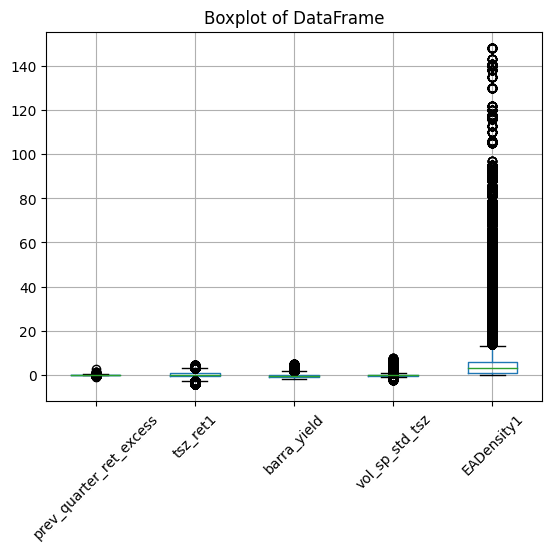

In [223]:
import pandas as pd
import matplotlib.pyplot as plt

def dataframe_summary(df):


    # 打印每列的统计量
    print("Statistics:")
    print(df.describe())
    print()

    # 计算每列的NAN值个数
    print("Number of NANs:")
    print(df.isnull().sum())
    print()

    # 计算每列的0值个数
    print("Number of 0:")
    print((df == 0).sum())
    print()

    # 绘制箱线图
    df.boxplot()
    plt.title("Boxplot of DataFrame")
    plt.xticks(rotation=45)
    plt.show()

# 查看DataFrame的摘要信息
dataframe_summary(df[features_ls])


## **Training and validation**
- Training period: From 2006 to 2016 (11 years)
- Validation period: From 2017 to 2020 (4 years)

### Plot the correlations

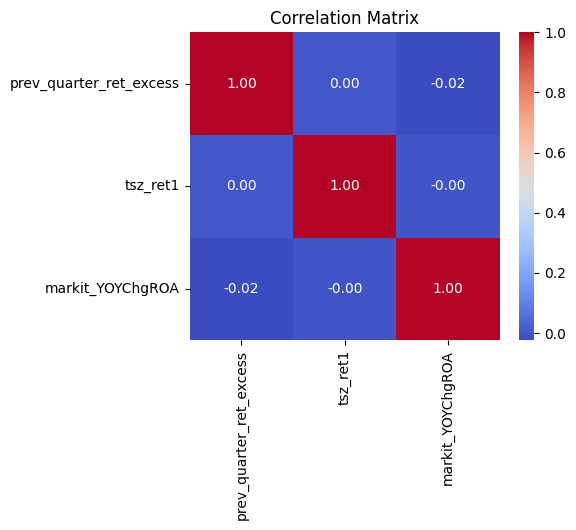

In [104]:
%matplotlib inline
plt.figure(figsize=(5, 4)) # adjust the figure size of the heatmap
correlation_matrix = df[features_ls].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [110]:
train_startdate = 20060101
train_enddate = 20161231

valid_startdate = 20170101
valid_enddate = 20201231

# split the df according to the periods of train/valid
train_mask = (df['dates'] >= train_startdate) & (df['dates'] <= train_enddate)
valid_mask = (df['dates'] >= valid_startdate) & (df['dates'] <= valid_enddate)

df_train = df[train_mask]
df_valid = df[valid_mask]
        
X_train,Y_train = df_train[features_ls].to_numpy(),df_train['target'].to_numpy()
X_valid,Y_valid = df_valid[features_ls].to_numpy(),df_valid['target'].to_numpy()

train_si,train_di = df_train['si'].values, df_train['di'].values
valid_si,valid_di = df_valid['si'].values, df_valid['di'].values

## **Model**

In [111]:
### ---- ---- ---- ---- Train your Model ---- ---- ---- ---- ###

from sklearn.ensemble import GradientBoostingRegressor

# train the model
regressor = GradientBoostingRegressor(n_estimators=400, learning_rate=0.10, max_depth=1, random_state=42)
regressor.fit(X_train, Y_train)

# predict
YPRED_train = regressor.predict(X_train)
YPRED_valid = regressor.predict(X_valid)

# alpha
alpha = np.full_like(data['ret1'], np.nan, dtype='float32', order='F')
alpha[train_si, train_di] = YPRED_train
alpha[valid_si, valid_di] = YPRED_valid

# accuracy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
acc_train = accuracy_score(Y_train>=0, YPRED_train>=0)
acc_valid = accuracy_score(Y_valid>=0, YPRED_valid>=0)
print(f'Accuracy Train: {acc_train :>.3%}')
print(f'Accuracy Valid: {acc_valid :>.3%}')

Accuracy Train: 51.379%
Accuracy Valid: 51.557%


## **Simulation**

##### Post Processing (PP) function
- PP function applies the final risk-management constraints on the signal and makes our signal tradeable in real markets
- PP function reduces the turnover and increases the liquidity which reduces the slippage costs

In [112]:
# PP function - No need to modify the code below

def post_processing(data, preA, booksize):
    lookback = 252
    
    apply_locates = data['apply_locates']
    preA1 = np.copy(preA)
    preA1 *= data['valids']
  
    postA = op.at_nan2zero(preA1)
    postA = op.ts_mean_exp(op.at_nan2zero(postA), 5, 2/5)
    
    postA = op.cs_poslimit(postA, 0.1)
    postA = op.cs_indneut(postA, data['sector'])
    postA = op.cs_shrink_balance(postA)                                            

    long_scaler = op.ts_max(np.nansum(postA*(postA>0),axis=0),lookback)            
    short_scaler = op.ts_max(np.nansum(np.abs(postA)*(postA<0),axis=0),lookback)   
    scaler = np.maximum(long_scaler,short_scaler)                                  
    postA = postA/scaler * booksize                                                
    
    postA = op.op_vmcont(postA, data['valids'], data['close'], data['vol20'],
                         maxtrd=0.05*(booksize/1e9), maxpos=0.5*(booksize/1e9))
    postA = op.tc_hump(postA, data['close'], hump_factor=1.0)                      
    postA = op.cs_shrink_balance(postA)                                            

    long_scaler = op.ts_max(np.nansum(postA*(postA>0),axis=0),lookback)
    short_scaler = op.ts_max(np.nansum(np.abs(postA)*(postA<0),axis=0),lookback)
    scaler = np.maximum(long_scaler,short_scaler)
    postA = postA/scaler * booksize

    postA = op.cs_poslimit(postA, 0.1)
    postA = op.cs_shrink_balance(postA)                                            
    postA = apply_locates(postA, data, data['locate_utilization_rate'], data['max_rebate_rate'])
    return postA

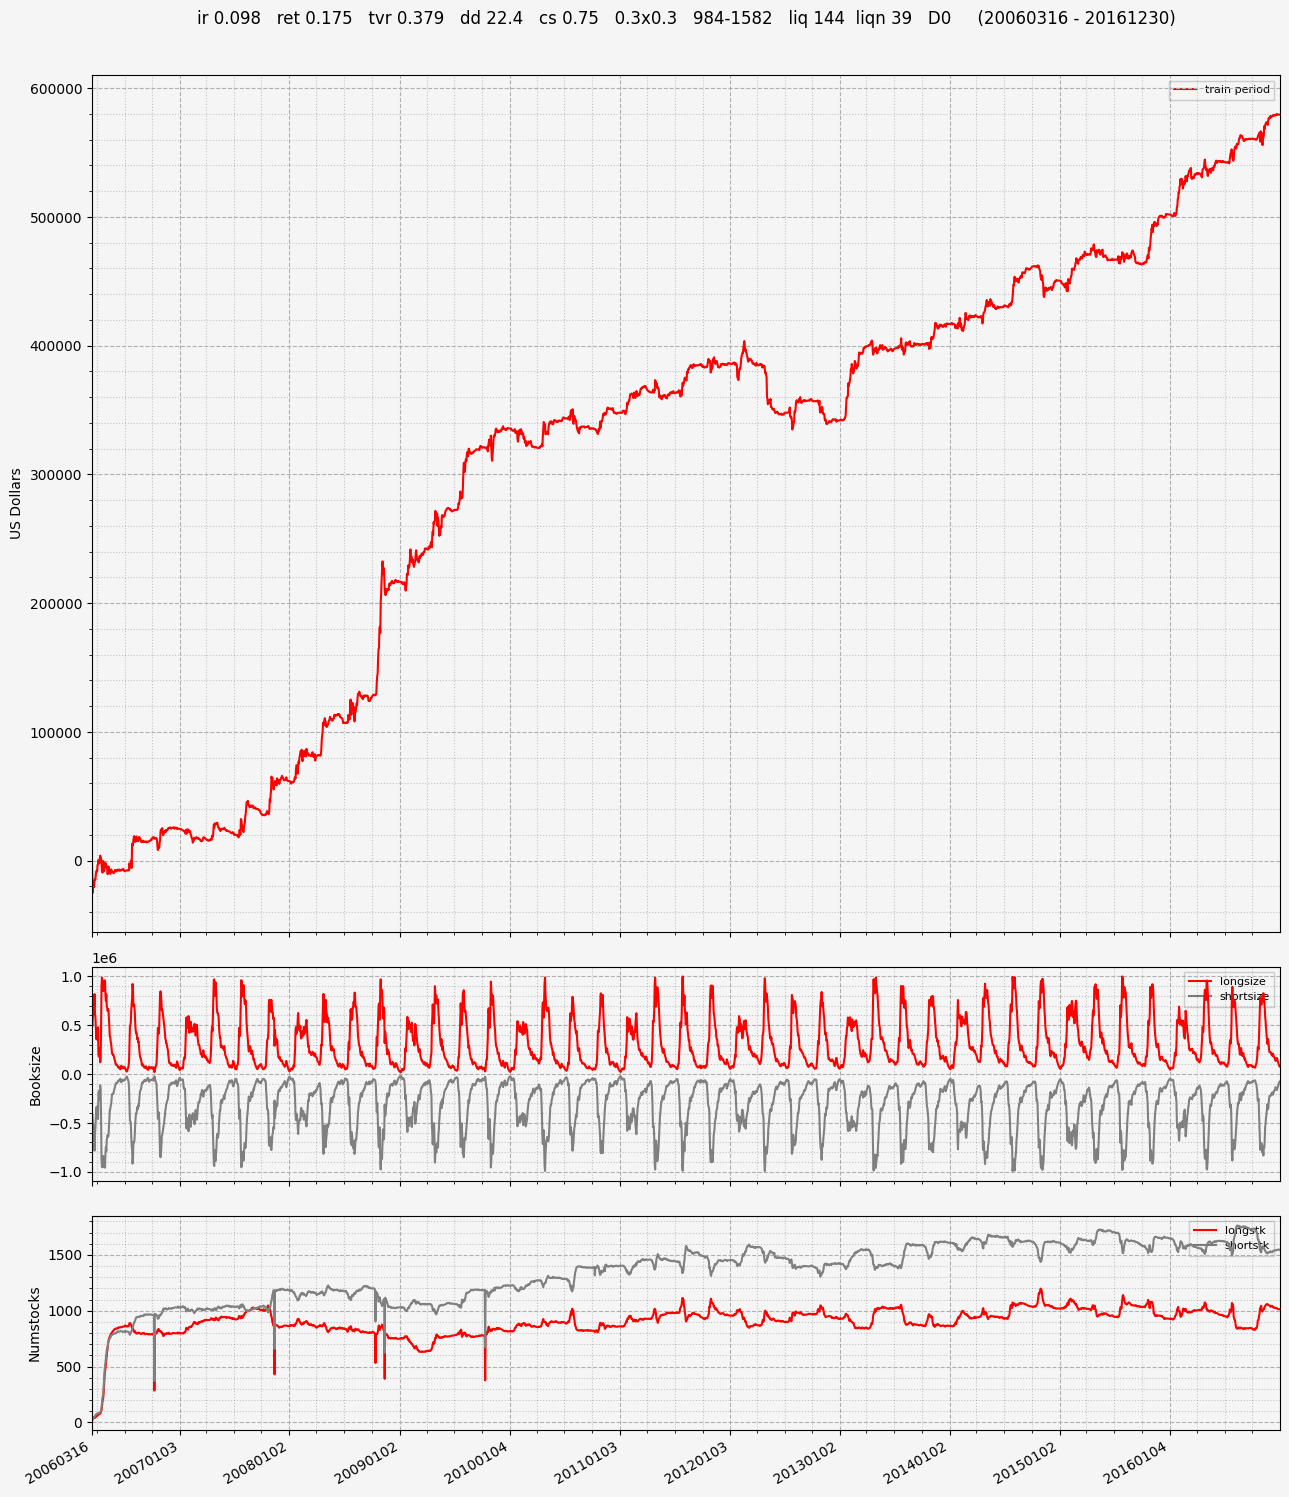

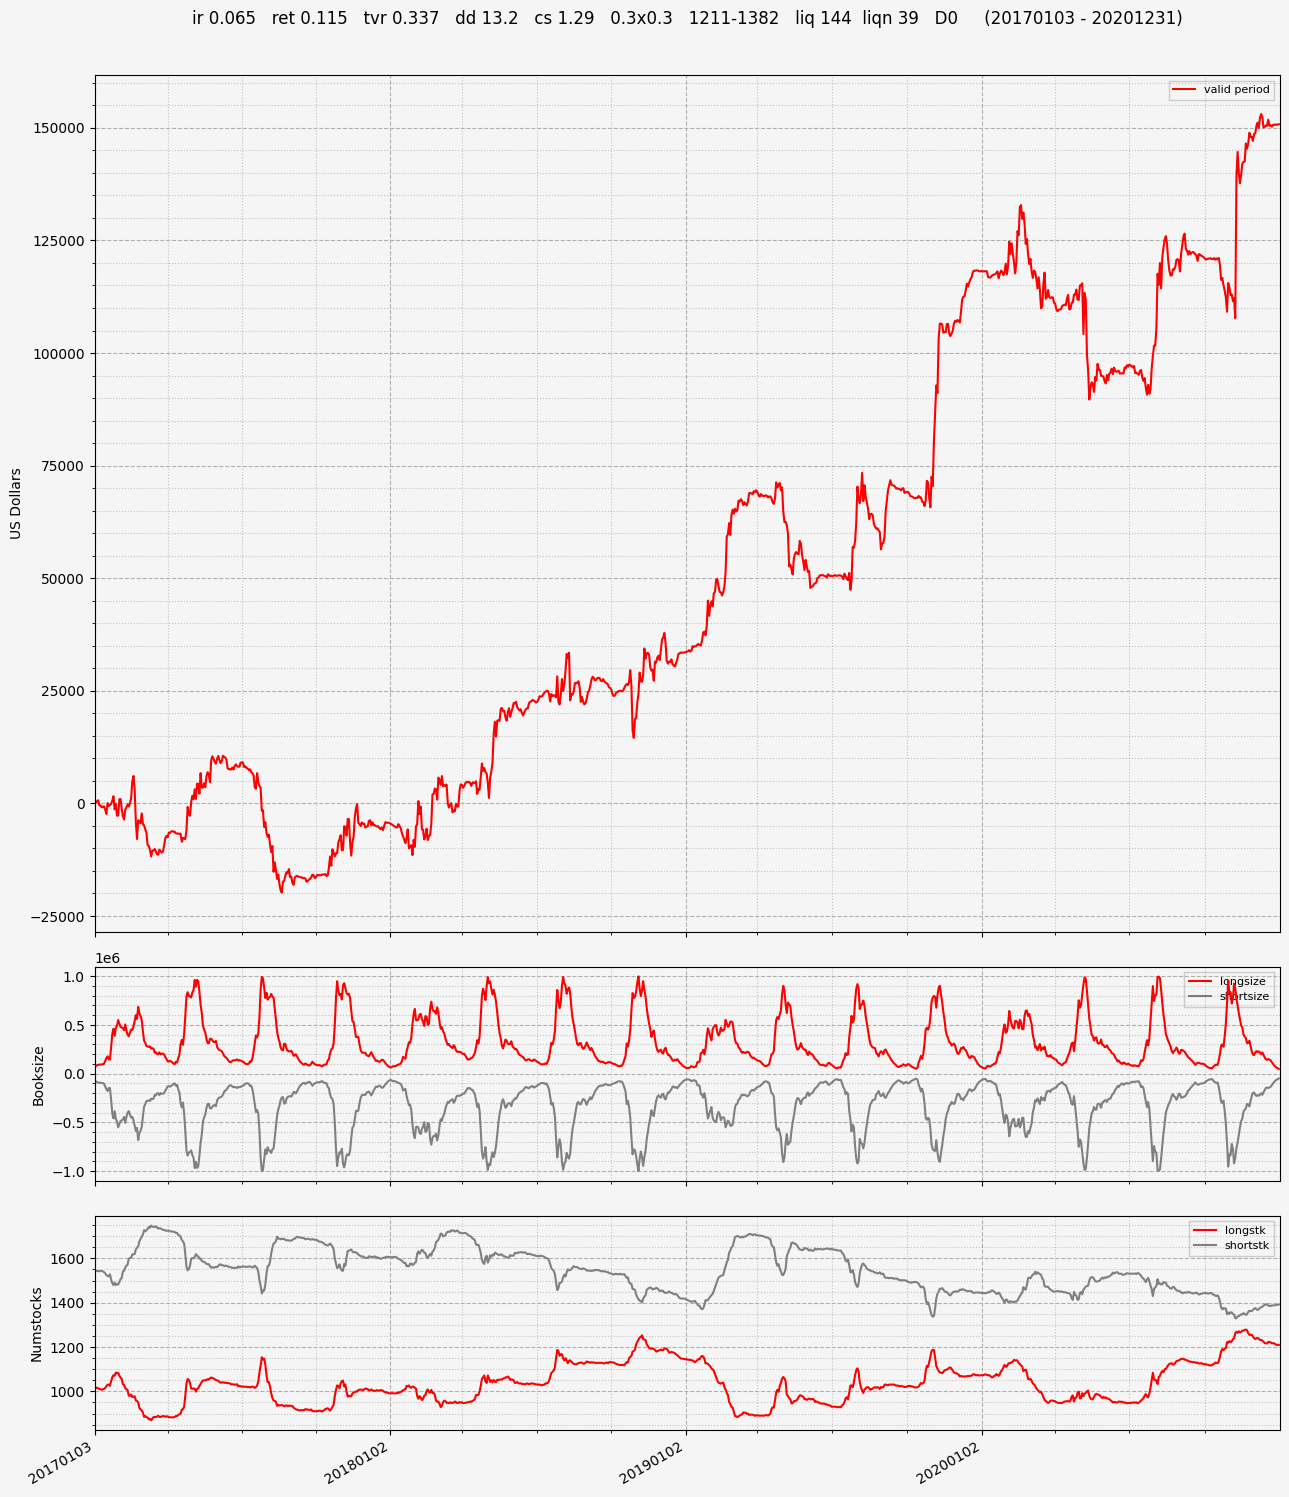

In [113]:
### ---- ---- ---- ---- No need to modify the code below ---- ---- ---- ---- ###
# simulation
postA = post_processing(data,alpha,data['booksize'])
postA[:, np.where(data['dates']>valid_enddate)[0][0]:]=np.nan # nan out values after valid_enddate
simres = op.op_simulate(data,postA,0,liq_on_valid_days=True,calc_liqn=True,slippage=True, slippage_model='fraction_spread', fraction_spread=0.2)

# simulation results
simres_train = op.cut_simres(simres,startdate=train_startdate,enddate=train_enddate)
simres_valid = op.cut_simres(simres,startdate=valid_startdate,enddate=valid_enddate)

# pnl plots
%matplotlib inline
op.op_plot(op.cut_simres(simres,startdate=train_startdate,enddate=train_enddate),label='train period')
op.op_plot(op.cut_simres(simres,startdate=valid_startdate,enddate=valid_enddate),label='valid period')

## **Summary**

In [114]:
# Summary on the Metrics
metrics = ['ir','ret','tvr','dd','liqn']
metrics_train = [acc_train*100]+[simres_train[mtc][-1] if isinstance(simres_train[mtc], np.ndarray) else simres_train[mtc] for mtc in metrics]
metrics_valid = [acc_valid*100]+[simres_valid[mtc][-1] if isinstance(simres_valid[mtc], np.ndarray) else simres_valid[mtc] for mtc in metrics]

pd.options.display.float_format = '{:.3f}'.format
simres_df = pd.DataFrame({"train":metrics_train,"valid":metrics_valid}, index=['accuracy']+metrics)
display(simres_df.T)

,accuracy,ir,ret,tvr,dd,liqn
train,51.379,0.098,0.175,0.379,22.444,39.102
valid,51.557,0.065,0.115,0.337,13.210,39.102


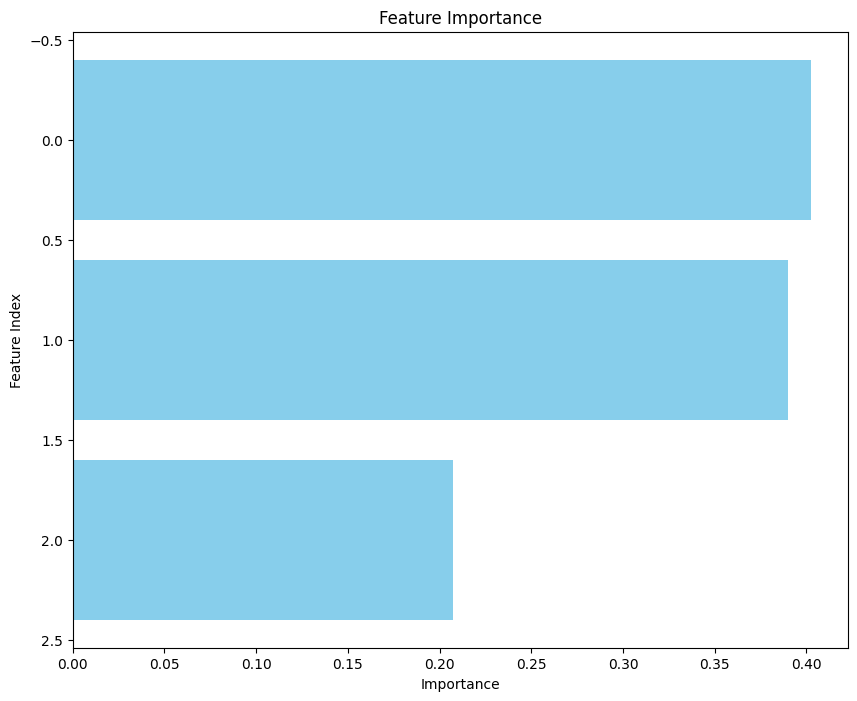

In [115]:
imp = regressor.feature_importances_
imp = pd.DataFrame(imp)

import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10, 8))
plt.barh(imp.index, imp[0], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature Index')
plt.title('Feature Importance')
plt.gca().invert_yaxis()  # 使得最高重要性在顶部显示
plt.show()

In [231]:
del df
import gc

gc.collect()

47195